## Churn Rate By Subscription Tier

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

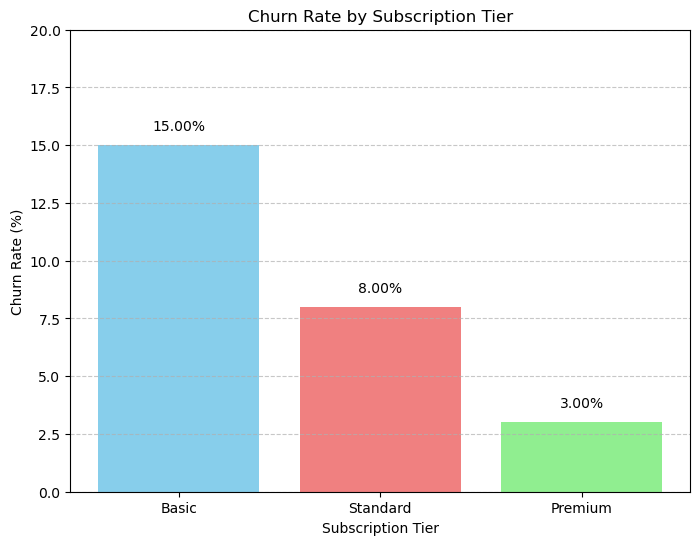

In [6]:
# Sample data
data = {'Subscription_Tier': ['Basic', 'Standard', 'Premium'],
        'Churn_Rate': [0.15, 0.08, 0.03]}  # Example churn rates

df = pd.DataFrame(data)

# Create the bar chart
plt.figure(figsize=(8, 6)) # Adjust figure size as needed
plt.bar(df['Subscription_Tier'], df['Churn_Rate'] * 100, color=['skyblue', 'lightcoral', 'lightgreen']) # Multiply by 100 to show as percentage
plt.xlabel('Subscription Tier')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Subscription Tier')
plt.ylim(0, 20) # Set a reasonable y-axis limit
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a horizontal grid for readability

# Add value labels on top of the bars
for index, value in enumerate(df['Churn_Rate'] * 100):
    plt.text(index, value + 0.5, f'{value:.2f}%', ha='center', va='bottom') # Format to 2 decimal places and add '%'

plt.show()

## Churn Rate over Time (Line Graph)

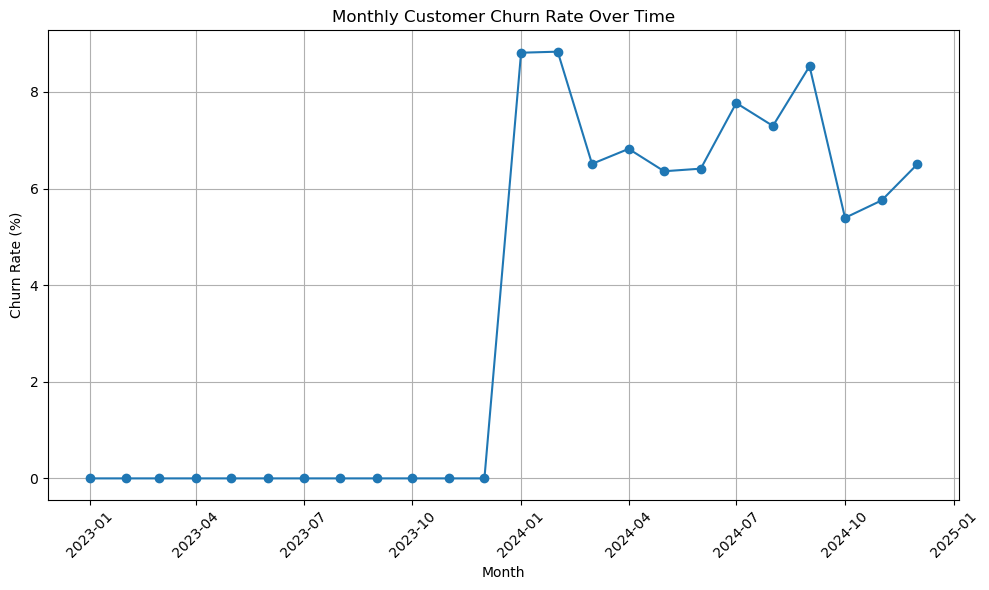

In [10]:
# Simulate customer data (replace with your actual data)
data = {
    'customer_id': range(1, 1001),
    'start_date': pd.to_datetime(np.random.choice(pd.date_range('2023-01-01', '2024-12-31', freq='D'), 1000)),
    'end_date': pd.to_datetime(np.random.choice(pd.date_range('2024-01-01', '2025-06-30', freq='D'), 1000))
}
df = pd.DataFrame(data)

# Assume some churn occurs (for demonstration)
churn_dates = pd.to_datetime(np.random.choice(pd.date_range('2024-07-01', '2025-06-30', freq='D'), 200))
churn_customers = np.random.choice(df['customer_id'], 200, replace=False)
df.loc[df['customer_id'].isin(churn_customers), 'end_date'] = churn_dates

# Calculate monthly churn rate
df['churned_month'] = df['end_date'].dt.to_period('M')
df['start_month'] = df['start_date'].dt.to_period('M')

# Group by month and calculate churn rate
monthly_churn = []
for month in sorted(df['start_month'].unique()):
    customers_at_start = df[df['start_month'] <= month]['customer_id'].nunique()
    churned_this_month = df[(df['churned_month'] == month)]['customer_id'].nunique()
    if customers_at_start > 0:
        churn_rate = (churned_this_month / customers_at_start) * 100
        monthly_churn.append({'month': month.start_time, 'churn_rate': churn_rate})

churn_df = pd.DataFrame(monthly_churn)

# Plotting the line graph
plt.figure(figsize=(10, 6))
plt.plot(churn_df['month'], churn_df['churn_rate'], marker='o', linestyle='-')
plt.title('Monthly Customer Churn Rate Over Time')
plt.xlabel('Month')
plt.ylabel('Churn Rate (%)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Viewing Hours vs. Churn Status (Scatter Plot)

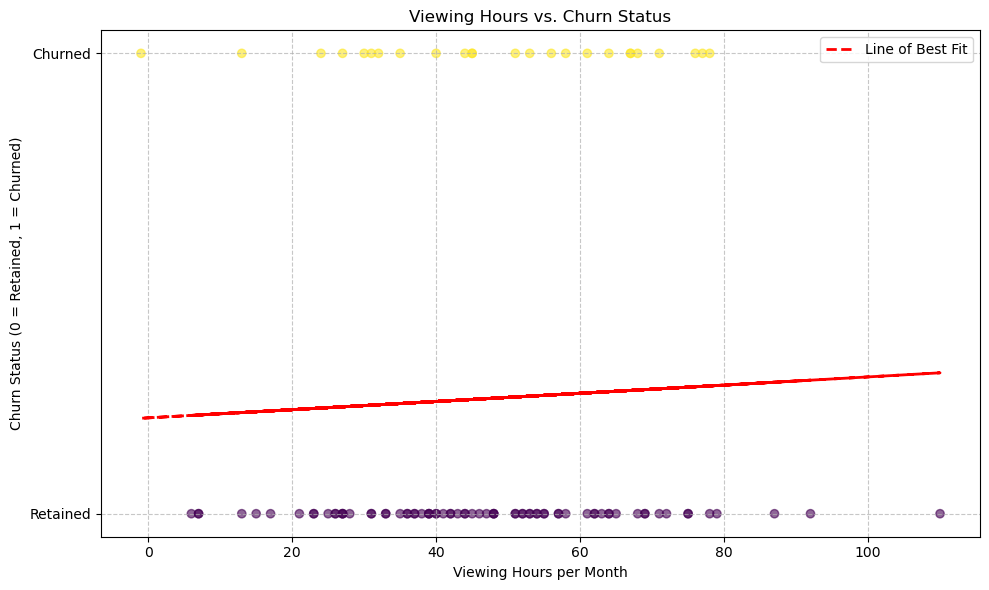

In [16]:
data = {
    'Viewing_Hours': np.random.normal(loc=50, scale=20, size=100).astype(int),
    'Churn_Status': np.random.choice(['Retained', 'Churned'], size=100, p=[0.7, 0.3])
}
df = pd.DataFrame(data)

# Create a numerical representation for 'Churn_Status' for the scatter plot
df['Churn_Numeric'] = df['Churn_Status'].apply(lambda x: 1 if x == 'Churned' else 0)

# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['Viewing_Hours'], df['Churn_Numeric'], alpha=0.6, c=df['Churn_Numeric'], cmap='viridis')

# Add labels and title
plt.xlabel("Viewing Hours per Month")
plt.ylabel("Churn Status (0 = Retained, 1 = Churned)")
plt.title("Viewing Hours vs. Churn Status")

# Customize y-axis ticks and labels
plt.yticks([0, 1], ['Retained', 'Churned'])

# Add a line of best fit (optional, but can help visualize trends)
# This will be a simple linear regression line
m, b = np.polyfit(df['Viewing_Hours'], df['Churn_Numeric'], 1)
plt.plot(df['Viewing_Hours'], m*df['Viewing_Hours'] + b, color='red', linestyle='--', linewidth=2, label='Line of Best Fit')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Distribution of Customer Support Interactions for Churned vs. Retained Customers (Histograms)

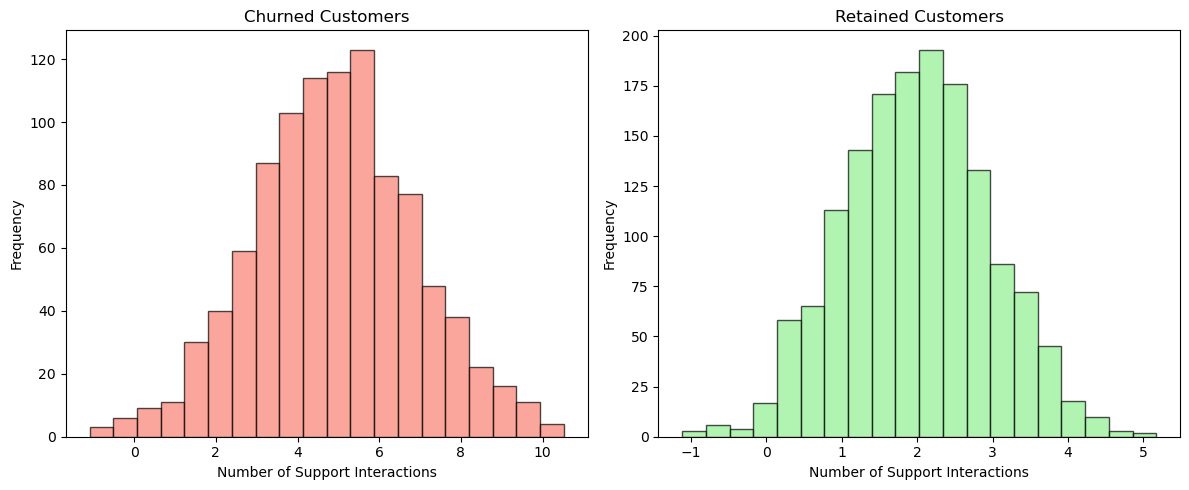

In [18]:
# Simulate data for churned and retained customers
# Replace this with your actual data
np.random.seed(0)  # for reproducibility
churned_interactions = np.random.normal(loc=5, scale=2, size=1000)  # Mean of 5 interactions for churned
retained_interactions = np.random.normal(loc=2, scale=1, size=1500) # Mean of 2 interactions for retained

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left histogram: Churned Customers
axes[0].hist(churned_interactions, bins=20, color='salmon', edgecolor='black', alpha=0.7)
axes[0].set_title('Churned Customers')
axes[0].set_xlabel('Number of Support Interactions')
axes[0].set_ylabel('Frequency')

# Right histogram: Retained Customers
axes[1].hist(retained_interactions, bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].set_title('Retained Customers')
axes[1].set_xlabel('Number of Support Interactions')
axes[1].set_ylabel('Frequency')

# Adjust layout and display the plots
plt.tight_layout() # Adjusts subplot parameters for a tight layout
plt.show()
